In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(8,5)

DATA_DIR= "../data/raw/"
train_df= pd.read_csv(DATA_DIR + "train.csv")

print("Train Shape:", train_df.shape)
train_df.head()


Train Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


=== Survived counts ===
Survived
0    549
1    342
Name: count, dtype: int64
=== Survived proportion ===
Survived
0    0.6162
1    0.3838
Name: proportion, dtype: float64


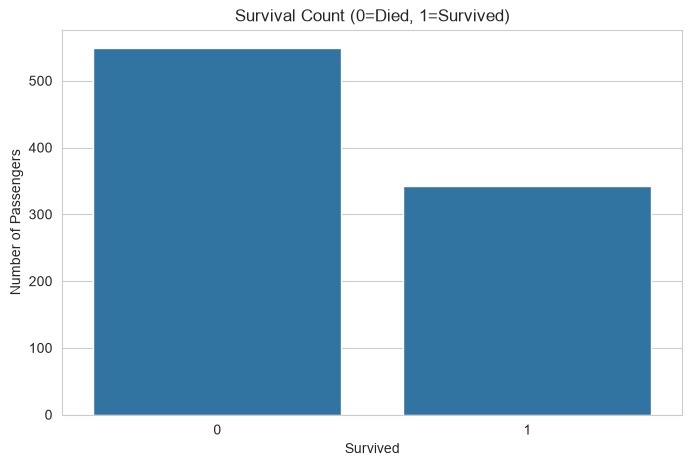

In [2]:
print("=== Survived counts ===")
print(train_df['Survived'].value_counts())

print("=== Survived proportion ===")
print(train_df['Survived'].value_counts(normalize=True).round(4))

sns.countplot(x='Survived', data=train_df)
plt.title("Survival Count (0=Died, 1=Survived)")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

=== Survival by Sex ===
Sex
female    0.7420
male      0.1889
Name: Survived, dtype: float64


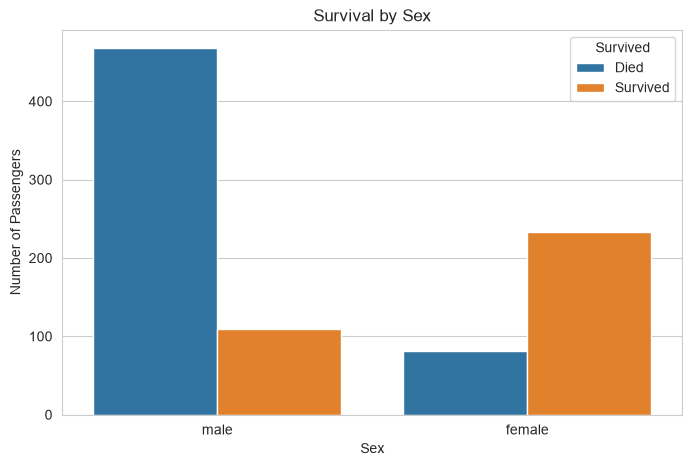

In [3]:
print("=== Survival by Sex ===")
print(train_df.groupby("Sex")["Survived"].mean().round(4))

sns.countplot(x="Sex",hue="Survived", data=train_df)
plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Died","Survived"])
plt.show()


=== Survival by Pclass ===
Pclass
1    0.6296
2    0.4728
3    0.2424
Name: Survived, dtype: float64


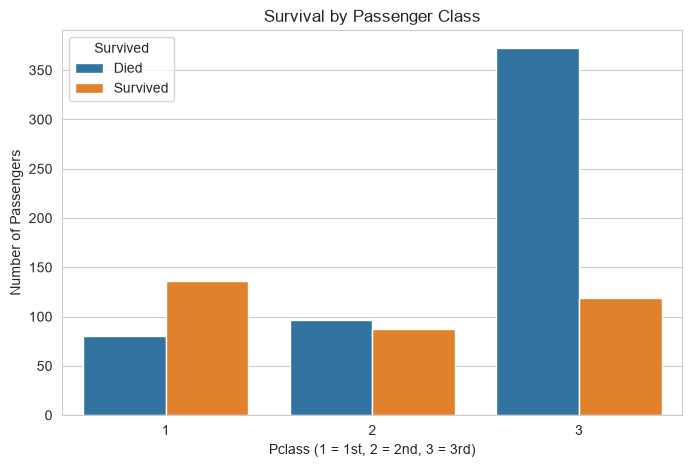

In [4]:
print("=== Survival by Pclass ===")
print(train_df.groupby("Pclass")["Survived"].mean().round(4))

sns.countplot(x="Pclass", hue="Survived", data=train_df)
plt.title("Survival by Passenger Class")
plt.xlabel("Pclass (1 = 1st, 2 = 2nd, 3 = 3rd)")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Died","Survived"])

plt.show()

=== Survival By Embarked ===
Embarked
C    0.5536
Q    0.3896
S    0.3370
Name: Survived, dtype: float64


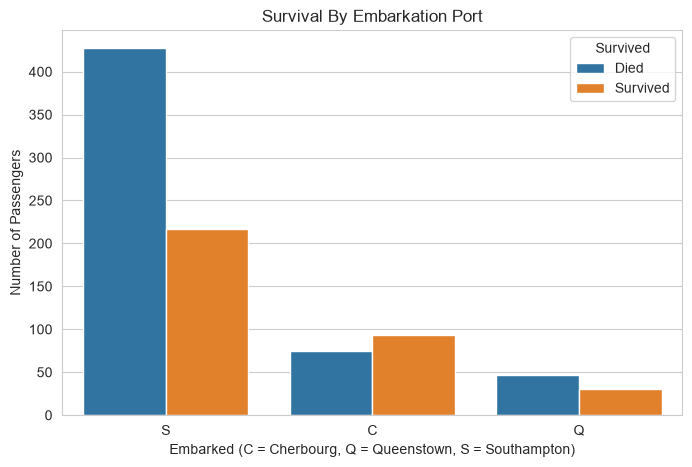

In [9]:
print("=== Survival By Embarked ===")
print(train_df.groupby("Embarked")["Survived"].mean().round(4))

sns.countplot(x="Embarked",hue="Survived",data=train_df)
plt.title("Survival By Embarkation Port")
plt.xlabel("Embarked (C = Cherbourg, Q = Queenstown, S = Southampton)")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Died","Survived"])


=== Age Statistics ===
count    714.00
mean      29.70
std       14.53
min        0.42
25%       20.12
50%       28.00
75%       38.00
max       80.00
Name: Age, dtype: float64

=== Missing Ages ===
Missing: 177 (19.87%)


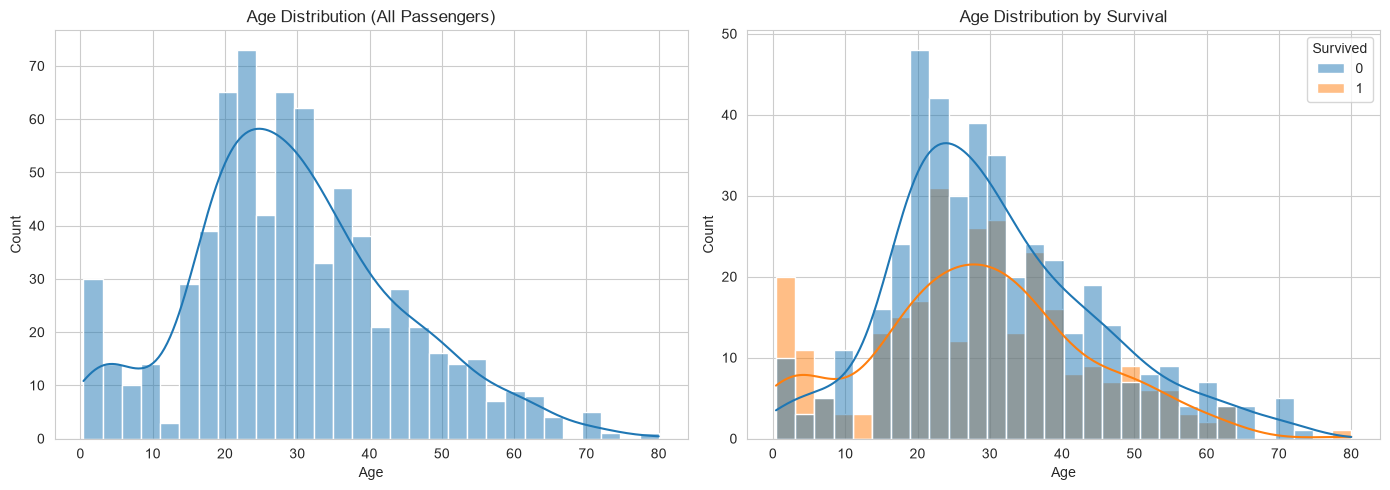

In [23]:

print("=== Age Statistics ===")
print(train_df["Age"].describe().round(2))

print("\n=== Missing Ages ===")
print(f"Missing: {train_df['Age'].isnull().sum()} ({train_df['Age'].isnull().mean()*100:.2f}%)")

# Distribution overall + by survival
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_df["Age"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution (All Passengers)")
axes[0].set_xlabel("Age")

sns.histplot(data=train_df, x="Age", hue="Survived", bins=30, kde=True, ax=axes[1])
axes[1].set_title("Age Distribution by Survival")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

=== Fare Statistics ===
count    891.00
mean      32.20
std       49.69
min        0.00
25%        7.91
50%       14.45
75%       31.00
max      512.33
Name: Fare, dtype: float64

 ===Missing values ===
Missing: 0(0.00)


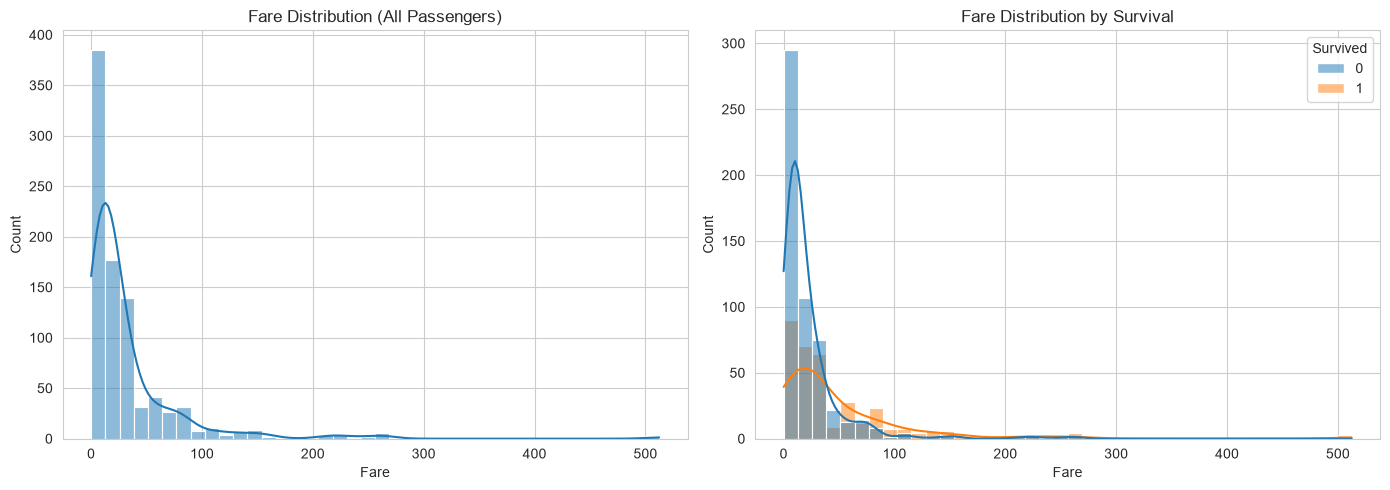

In [29]:
print("=== Fare Statistics ===")
print(train_df['Fare'].describe().round(2))

print("\n ===Missing values ===")
print(f"Missing: {train_df['Fare'].isnull().sum()}({train_df['Fare'].isnull().mean()*100:.2f})")

fig,axes= plt.subplots(1,2, figsize=(14,5))

sns.histplot(train_df['Fare'], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Fare Distribution (All Passengers)")
axes[0].set_xlabel("Fare")

sns.histplot(data=train_df, x="Fare", hue="Survived", bins=40, kde=True, ax=axes[1])
axes[1].set_title("Fare Distribution by Survival")
axes[1].set_xlabel("Fare")

plt.tight_layout()
plt.show()

=== Correlation Matrix ===
          Survived  Pclass   Age  SibSp  Parch  Fare
Survived      1.00   -0.34 -0.08  -0.04   0.08  0.26
Pclass       -0.34    1.00 -0.37   0.08   0.02 -0.55
Age          -0.08   -0.37  1.00  -0.31  -0.19  0.10
SibSp        -0.04    0.08 -0.31   1.00   0.41  0.16
Parch         0.08    0.02 -0.19   0.41   1.00  0.22
Fare          0.26   -0.55  0.10   0.16   0.22  1.00


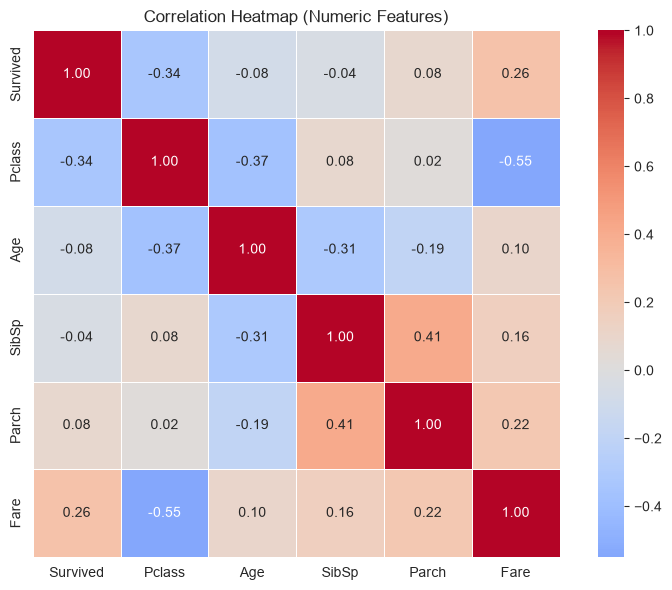

In [30]:
# Block 8: Correlation heatmap (numeric features only)
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr = train_df[numeric_cols].corr().round(2)

print("=== Correlation Matrix ===")
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()